# Module 05, 06 & 07 Assignment
## Understanding the ML Problem, Exploratory Data Analysis (EDA) and Basic Preprocessing
**Dataset:** Titanic – Machine Learning from Disaster (Kaggle)

Download the **train.csv** file from Kaggle’s Titanic competition and upload it to this notebook. Rename it to `titanic.csv` or update the file name in the loading cell.
Dataset link: https://www.kaggle.com/datasets/yasserh/titanic-dataset

Total Marks: **100**

### Instructions
- This assignment covers:
  - **Module 05:** Basic ML problem framing (features, target, task type).
  - **Module 06:** Exploratory Data Analysis (EDA).
  - **Module 07:** Basic Preprocessing (handling missing values, encoding, scaling).
- Answer all questions inside this notebook using code and markdown.
- Do not delete the original question texts.
- At the end, the notebook should run from top to bottom without errors.

## 🎯 এই Assignment থেকে কী Achieve করতে চাই?

এই assignment-এ Titanic dataset ব্যবহার করে তিনটি Module-এর শিক্ষা একসাথে প্রয়োগ করা হবে।

**মূল লক্ষ্য:** একজন Titanic যাত্রীর তথ্য দেখে predict করা — সে বেঁচে ছিল কিনা।

---

## ✅ এই Assignment থেকে কী Achieve করতে পারব?

| Part | বিষয় | শিখব |
|---|---|---|
| **Part 0** | ML Problem বোঝা | Target, Feature, Task Type চেনা |
| **Part A** | EDA | Data বোঝা, pattern খোঁজা, chart বানানো |
| **Part B** | Preprocessing | Missing values, Encoding, Scaling |

---

## 🧠 এখন পর্যন্ত যা শিখেছি, সেই আলোকে চিন্তার উপায়

| আগে যা শিখেছি | এখানে কীভাবে লাগবে |
|---|---|
| **Classification vs Regression** | `Survived` = 0 বা 1 → এটি classification |
| **Missing Values** | `Age` (177 missing), `Cabin` (687 missing), `Embarked` (2 missing) |
| **Encoding** | `Sex`, `Embarked`, `Pclass` → text/category → number করতে হবে |
| **Scaling** | `Age` (0–80) vs `Fare` (0–512) — range অনেক আলাদা, scale করতে হবে |
| **Correlation** | `Fare` (+0.26) সবচেয়ে বেশি correlated — বেশি ভাড়া = বেঁচে থাকার chance বেশি |

---

## 🗺️ Approach

```
Step 1 → Dataset load করো, দেখো
Step 2 → Target ও features identify করো
Step 3 → EDA — histogram, countplot, heatmap, pairplot
Step 4 → Preprocessing — missing values fix, encode, scale
Step 5 → Final dataset ready করো
```

In [1]:
# ==============================
# Setup
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported.")

Libraries imported.


উপরের code-এ EDA ও Preprocessing-এর জন্য দরকারি সব library import করা হয়েছে।
`sns.set(style="whitegrid")` দিয়ে সব chart-এ সুন্দর grid style set হয়েছে।

---
## Part 0: Understanding the ML Problem (Module 05) – 10 marks

### 0.1 Load the Dataset and Inspect (5 marks)
**Tasks:**
1. Load `titanic.csv` into a pandas DataFrame.
2. Show `.head()`, `.info()`, and `.describe()`.
3. Briefly look at the column names and data types.


In [ ]:
# 0.1 Load the Dataset and Inspect
# TODOs: Change file name if needed.

# Now we load the dataset — works in both Google Colab and local IDE
import os

try:
    # Google Colab path — shows a file picker to upload the file
    import google.colab
    from google.colab import files
    print("Running on Google Colab. Please upload titanic.csv")
    uploaded = files.upload()
    CSV_FILE = list(uploaded.keys())[0]
except ImportError:
    # Local IDE path — reads from the same folder as this notebook
    CSV_FILE = "titanic.csv"
    if not os.path.exists(CSV_FILE):
        raise FileNotFoundError("Place titanic.csv in the same folder as this notebook.")
    print(f"Running locally — loading: {CSV_FILE}")

# Here we have loaded the CSV into a DataFrame called df
df = pd.read_csv(CSV_FILE)

print("Shape of dataset:", df.shape)
display(df.head())

print("\nInfo:")
print(df.info())

print("\nDescribe (numeric columns):")
display(df.describe())

**এই code-এ কী করা হয়েছে:**

`pd.read_csv()` দিয়ে CSV file পড়ে `df` নামের DataFrame-এ রাখা হয়েছে।
এই code Google Colab-এ চালালে file picker খুলবে — সেখান থেকে `titanic.csv` select করো।
Local IDE-তে চালালে notebook-এর পাশের folder থেকে automatically load হবে।

**`.head()`** → প্রথম 5 row দেখায়
**`.info()`** → প্রতিটি column-এর dtype ও missing count দেখায়
**`.describe()`** → numeric column-গুলোর mean, min, max, quartile দেখায়

**লক্ষ্যনীয়:**
- Dataset-এ **891 rows ও 12 columns** আছে
- `Age`-এ 714 non-null → 177টি missing
- `Cabin`-এ মাত্র 204 non-null → 687টি missing (77%!)
- `Sex`, `Embarked` text column — পরে encode করতে হবে

### 0.2 Identify Features, Target and Task Type (5 marks)
**Tasks:**
Based on the dataset:
1. Identify the **target variable** for a predictive model.
2. List at least **5 potential feature columns** you could use.
3. State whether this is a **classification** or **regression** problem, and explain **why**.

Write your answers below.


#### **Your answers**

- **Target variable:** `Survived` — এই column predict করতে হবে (0 = মারা গেছে, 1 = বেঁচেছে)

- **Feature columns (at least 5):**
  1. `Pclass` — ticket class (1st, 2nd, 3rd)
  2. `Sex` — gender (male/female)
  3. `Age` — passenger age
  4. `Fare` — ticket price paid
  5. `SibSp` — siblings and spouses on board
  6. `Parch` — parents and children on board
  7. `Embarked` — port of boarding (S, C, Q)

- **Is this classification or regression, and why?**
  This is a **classification** problem. The target column `Survived` has only two values — 0 (did not survive) and 1 (survived). We are predicting which category a passenger falls into, not a continuous number. So it is binary classification.

---
## Part A: Exploratory Data Analysis (EDA) – 45 marks

### 1. Initial Exploration and Cleaning Decisions (10 marks)
**Tasks:**
1. Show the number of unique values in each column.
2. Identify columns that are clearly **IDs or high-cardinality text** (for example, `PassengerId`, `Name`, `Ticket`).
3. Decide which of these columns you will **drop** for the rest of the analysis and justify in 2–3 sentences.


In [3]:
# 1. Initial Exploration and Cleaning Decisions (Task 1 is given)
print("Unique values per column:")
for col in df.columns:
    print(col, ":", df[col].nunique())

Unique values per column:
PassengerId : 891
Survived : 2
Pclass : 3
Name : 891
Sex : 2
Age : 88
SibSp : 7
Parch : 7
Ticket : 681
Fare : 248
Cabin : 147
Embarked : 3


**এই code-এ কী করা হয়েছে:**

`df[col].nunique()` প্রতিটি column-এ কতটি unique value আছে সেটা বলে।

**দেখা যাচ্ছে:**
- `PassengerId` → 891 unique (প্রতিটি row আলাদা — শুধু ID, কোনো pattern নেই)
- `Name` → 891 unique (সবার নাম আলাদা — ML-এ কাজে আসবে না)
- `Ticket` → 681 unique (প্রায় সবার ticket number আলাদা)
- `Cabin` → 147 unique (কিন্তু 687টি missing — ব্যবহারযোগ্য নয়)

#### Columns to drop and justification

- **Columns dropped:** `PassengerId`, `Name`, `Ticket`, `Cabin`

- **Justification:**
  `PassengerId` is just a row number — it has no useful pattern for prediction.
  `Name` and `Ticket` both have nearly 891 unique values, so a machine learning model cannot learn any useful pattern from them.
  `Cabin` has 687 missing values out of 891 rows (77% missing), so it has very little usable data and should be dropped entirely.

---
### 2. Univariate Analysis (15 marks)
**Tasks:**
- Plot histograms for numeric features: `Age`, `Fare`, `SibSp`, `Parch`.
- Plot countplots for categorical features: `Sex`, `Pclass`, `Embarked`.
- Write **two to three insights** about the distributions and any obvious patterns.


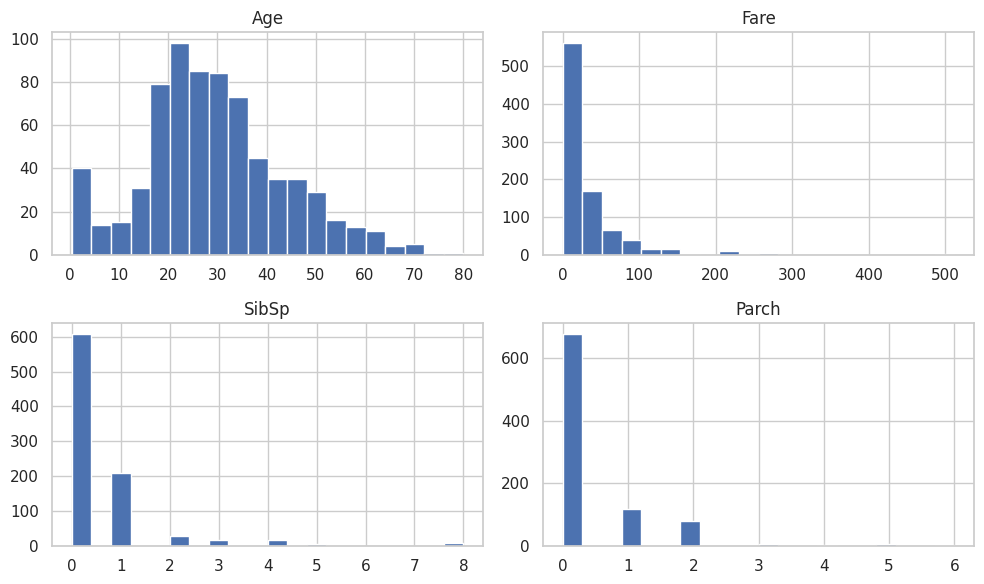

/tmp/ipykernel_42/1729846121.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_42/1729846121.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_42/1729846121.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="Set2")


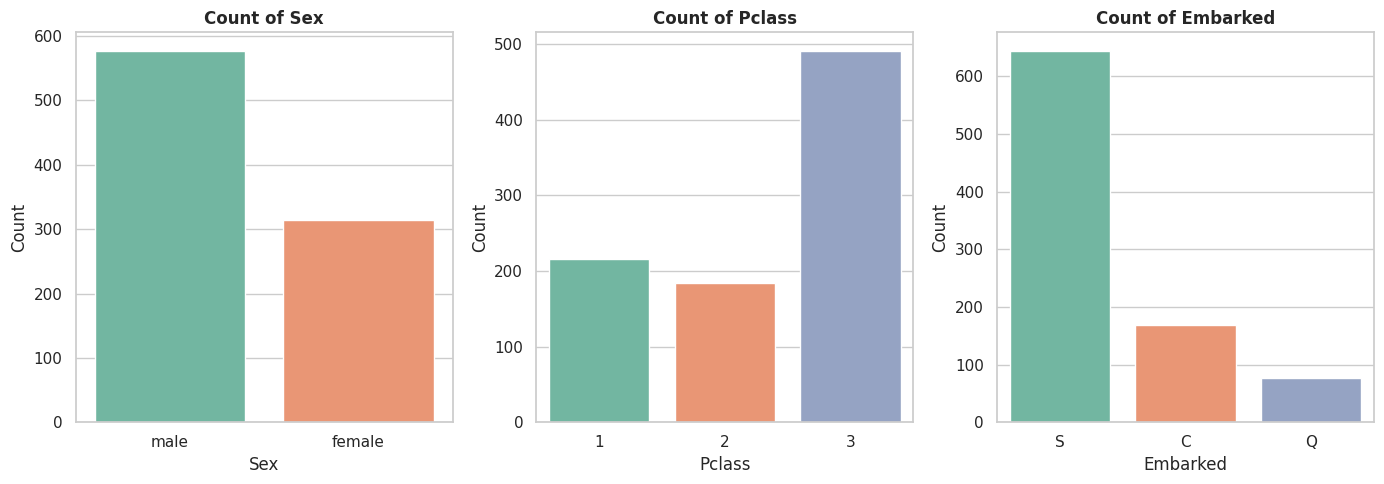

In [4]:
# 2. Univariate Analysis

numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

# Now we plot histograms — this code is already given in the assignment
df[numeric_cols].hist(bins=20, figsize=(10, 6))
plt.tight_layout()
plt.show()

# Now we write the countplot code for categorical columns
cat_cols = ["Sex", "Pclass", "Embarked"]

# Here we draw one countplot for each categorical column side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"Count of {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

### 📊 এই Charts আমরা কীভাবে Observe করব?

**Histogram (Numeric features):**
- X-axis = feature-এর value range, Y-axis = কতজন সেই range-এ পড়ে
- বেশিরভাগ bar বামদিকে থাকলে = **right-skewed** (কিছু অনেক বড় value আছে)
- Mean ও Median কাছাকাছি থাকলে = symmetric distribution

**Countplot (Categorical features):**
- X-axis = প্রতিটি category, Y-axis = সেই category-তে কতজন passenger
- কোন bar উঁচু সেটা দেখো — সেটাই সবচেয়ে বেশি আসা category

### 📊 এই Charts থেকে আমরা কী কী Observe করলাম?

#### Write Your insights

- **Insight 1:**
  Most passengers were male (about 577 male vs 314 female). Also, most passengers traveled in 3rd class (Pclass=3). This shows the dataset has more lower-class male passengers.

- **Insight 2:**
  The `Age` histogram shows most passengers were between 20–40 years old. The `Fare` histogram is heavily right-skewed — most passengers paid a small fare, but a few paid very high prices (up to $512). This means Fare has big outliers.

- **Insight 3:**
  Most passengers boarded from Southampton (S). The `SibSp` and `Parch` columns show that most passengers (median = 0) traveled alone, without any family members on board.

---
### 3. Bivariate Analysis with Target (15 marks)
Use `Survived` as the target variable.

**Tasks:**
- Compute and plot a **correlation heatmap** for numeric features, including `Survived`.
- Create a **pairplot** for: `Age`, `Fare`, `SibSp`, `Parch`, and `Survived`.
- Write **two to three insights**, including which variables seem associated with survival.


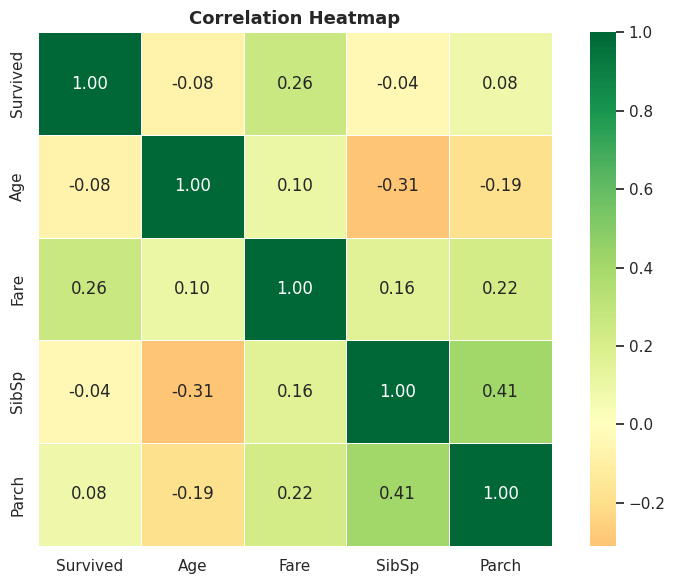

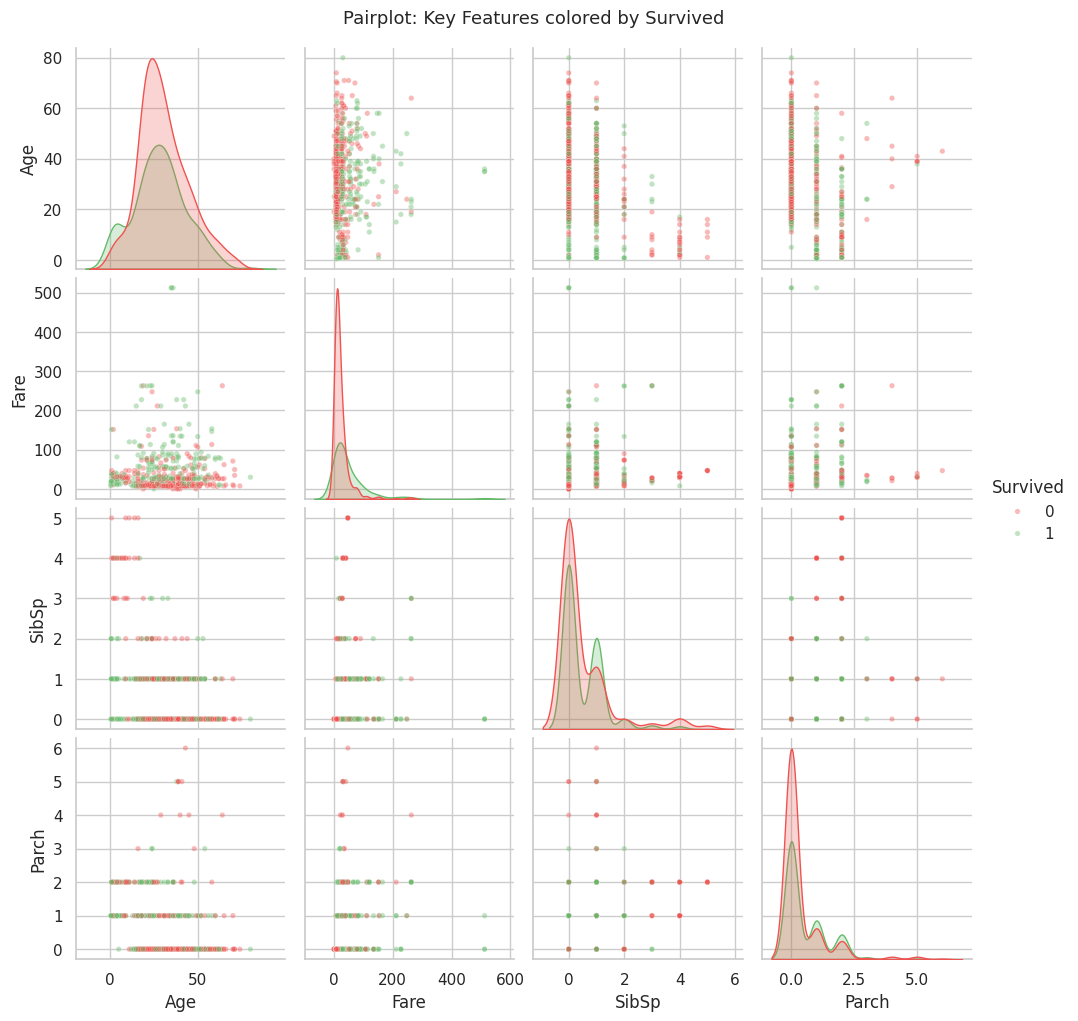

In [5]:
# 3. Bivariate Analysis with Target

num_for_corr = ["Survived", "Age", "Fare", "SibSp", "Parch"]

# Now we compute the correlation matrix and draw a heatmap
corr_matrix = df[num_for_corr].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True
)
plt.title("Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Now we create a pairplot colored by Survived
# Here we drop rows where Age is missing so pairplot works correctly
pairplot_cols = ["Age", "Fare", "SibSp", "Parch", "Survived"]
df_pair = df[pairplot_cols].dropna()

g = sns.pairplot(
    df_pair,
    hue="Survived",
    palette={0: "#EF5350", 1: "#66BB6A"},
    plot_kws=dict(alpha=0.4, s=15),
    diag_kind="kde"
)
g.figure.suptitle("Pairplot: Key Features colored by Survived", y=1.02, fontsize=13)
plt.show()

### 📊 Correlation Heatmap কীভাবে Observe করব?

- **গাঢ় সবুজ (+1 কাছে)** → একটা বাড়লে অন্যটাও বাড়ে (positive correlation)
- **গাঢ় লাল (-1 কাছে)** → একটা বাড়লে অন্যটা কমে (negative correlation)
- **হলুদ (0 কাছে)** → কোনো linear সম্পর্ক নেই
- **`Survived` row দেখো** — এই row-এ কোন feature-এর সাথে সবচেয়ে বেশি correlated সেটা বোঝা যাবে

### 📊 Pairplot কীভাবে Observe করব?

- **সবুজ dot** = survived (1), **লাল dot** = not survived (0)
- **Diagonal** → সেই feature-এর KDE distribution — সবুজ ও লাল peak আলাদা জায়গায় থাকলে ভালো predictor
- **Off-diagonal** → দুটো feature-এর scatter plot — দুই color আলাদা cluster করলে ভালো

### 📊 এই Charts থেকে কী Observe করলাম?

#### Your insights

- **Insight 1:**
  `Fare` has the strongest positive correlation with `Survived` (+0.26). Passengers who paid more (higher class) had a better chance of surviving. `Age` has a small negative correlation (-0.08), meaning slightly younger passengers survived a bit more.

- **Insight 2:**
  In the pairplot, the `Fare` diagonal shows green (survived) peaks at higher fare values. This confirms that higher-paying passengers (1st class) were more likely to survive. `SibSp` and `Parch` show weak separation between the two groups.

- **Insight 3:**
  `SibSp` and `Parch` are mildly correlated with each other (+0.41), which makes sense — people traveling with family tend to have both siblings and children on board at the same time.

---
### 4. Categorical vs Target Analysis (5 marks)
**Tasks:**
For each of the following categorical features: `Sex`, `Pclass`, `Embarked`:
- Plot a **bar chart** showing the proportion of passengers who survived in each category.
- Write **two short insights** about which categories have higher or lower survival chances.



Survival proportion by Sex:


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


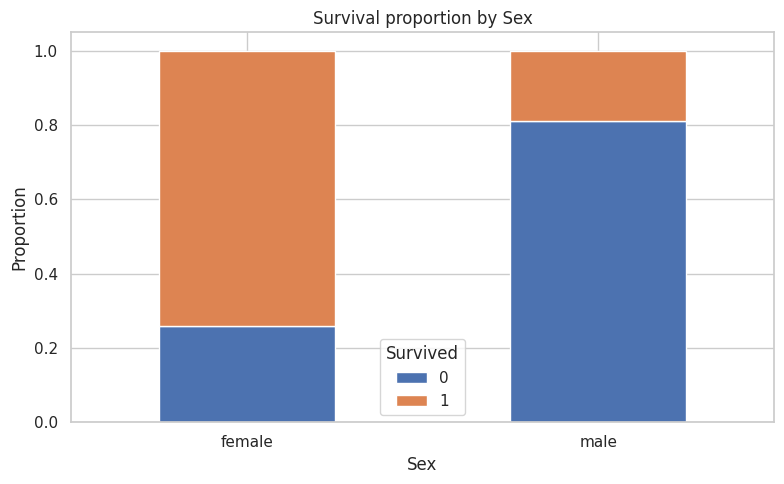


Survival proportion by Pclass:


Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


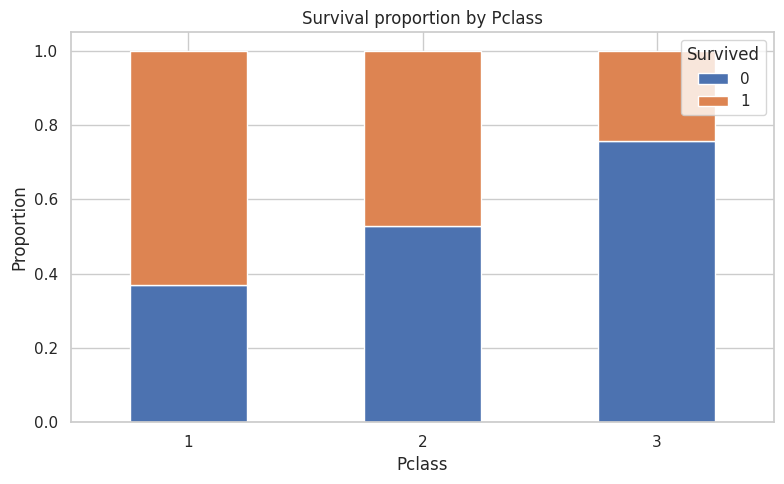


Survival proportion by Embarked:


Survived,0,1
Embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


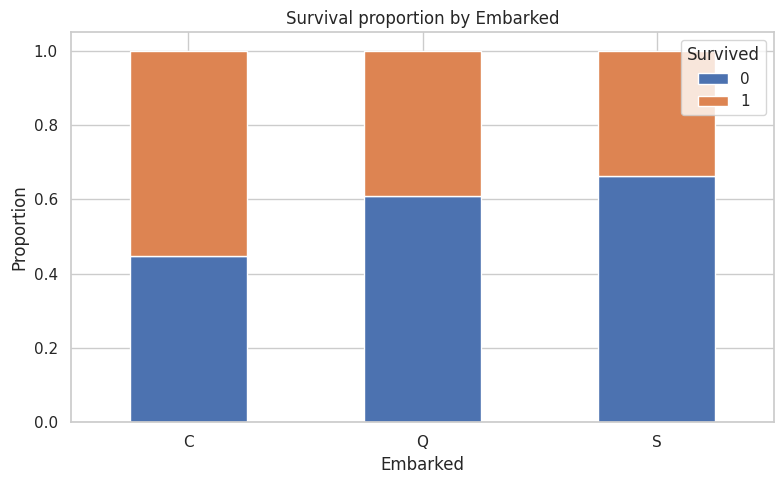

In [6]:
# 4. Categorical vs Target Analysis [Bar chart code is written for you]

cat_target_cols = ["Sex", "Pclass", "Embarked"]

for c in cat_target_cols:
    ct = pd.crosstab(df[c], df["Survived"], normalize="index")
    print(f"\nSurvival proportion by {c}:")
    display(ct)
    ct.plot(kind="bar", stacked=True)
    plt.title(f"Survival proportion by {c}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

### 📊 এই Stacked Bar Charts কীভাবে Observe করব?

- প্রতিটি bar মোট 100% proportion — নীল অংশ = not survived (0), কমলা = survived (1)
- একটা category-র survived অংশ যত বড়, সেখানে survival rate তত বেশি
- X-axis-এ category, Y-axis-এ proportion (0 থেকে 1)

### 📊 এই Charts থেকে কী Observe করলাম?

#### Your insights

- **Insight 1:**
  Female passengers had a survival rate of about **74%**, while male passengers had only **19%**. This huge difference shows that gender (`Sex`) is the most powerful predictor of survival. The "women and children first" rule is clearly visible in the data.

- **Insight 2:**
  1st class passengers survived at about **63%**, while 3rd class passengers survived at only **24%**. Passengers from Cherbourg (C) had the highest survival rate, likely because more 1st class passengers boarded from there.

---
## Part B: Basic Data Preprocessing – 45 marks

Focus: **Handling missing values, encoding categorical variables, and scaling numeric features.**

### 5. Handling Missing Values (10 marks)
**Tasks:**
1. Show the count of missing values in each column.
2. Decide how to handle missing values for:
   - `Age` (numeric)
   - `Embarked` (categorical)
   - `Cabin` (many missing values)
3. Implement your chosen strategy in code.
4. Show missing value counts again to confirm.
5. Explain your choices in **3–4 sentences**.


In [7]:
# 5. Handling Missing Values

print("Missing values before:") #[Task 1 is done for you]
print(df.isna().sum())

# Now we drop the Cabin column — it has 77% missing values
df = df.drop(columns=["Cabin"])

# Now we also drop columns that are not useful for ML
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

# Now we fill Age missing values with the median age
# We use median because Age has some outliers — median is more robust
age_median = df["Age"].median()
df["Age"] = df["Age"].fillna(age_median)

# Now we fill Embarked missing values with the mode (most common boarding port)
# Only 2 values are missing so mode is the safest and simplest choice
embarked_mode = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(embarked_mode)

print("\nMissing values after handling:")
print(df.isna().sum())

print("\nDataFrame shape after cleaning:", df.shape)
display(df.head())

Missing values before:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

DataFrame shape after cleaning: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


**এই code-এ কী কী করা হয়েছে:**

- `df.drop(columns=["Cabin"])` → Cabin column সরিয়ে দেওয়া হয়েছে (77% missing)
- `df.drop(columns=["PassengerId","Name","Ticket"])` → এই columns ML-এ কাজে আসে না, তাই drop
- `df["Age"].fillna(age_median)` → Age-এর 177টি missing value-এ median age বসানো হয়েছে
- `df["Embarked"].fillna(embarked_mode)` → Embarked-এর 2টি missing value-এ mode ("S") বসানো হয়েছে

**পরিবর্তন লক্ষ্যনীয়:**
- Shape: (891, 12) → **(891, 8)** — 4টি column কমেছে
- Missing values এখন **সব column-এ 0** — সম্পূর্ণ clean

#### Explanation of your strategy

- **Why you dropped or kept `Cabin`:**
  `Cabin` had 687 missing values out of 891 rows — that is 77% missing. When more than half the data is missing, filling it would be mostly guessing. So it is better to drop it completely.

- **Why you used median for `Age`:**
  We used **median** instead of mean because median is not affected by outliers. Some passengers are very old (80 years) and these outliers can pull the mean higher. Median gives a better "middle" estimate.

- **Why you used mode for `Embarked`:**
  Only **2 values** are missing in `Embarked`. The mode (most common value = "S") is the safest and simplest choice for just 2 missing rows.

---
### 6. Encoding Categorical Variables (15 marks)
Focus on the following categorical features:
- `Sex`
- `Embarked`
- `Pclass` (treat as categorical)

**Tasks:**
- Use `OneHotEncoder` from sklearn to encode these features.
- Keep `Survived` and the main numeric features (`Age`, `Fare`, `SibSp`, `Parch`).
- Show the shape and head of the encoded DataFrame.


In [8]:
# 6. Encoding Categorical Variables

df_enc = df.copy()

# Select features for encoding and keep important numeric ones
cat_features     = ["Sex", "Embarked", "Pclass"]
numeric_features = ["Age", "Fare", "SibSp", "Parch"]
target_col       = "Survived"

# Now we set up the OneHotEncoder
# sparse_output=False gives us a regular array instead of a sparse matrix
# handle_unknown="ignore" means no crash if new values appear later
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Here we fit and transform the three categorical columns
encoded_array = encoder.fit_transform(df_enc[cat_features])

# Here we get the column names the encoder created (like Sex_male, Sex_female)
encoded_col_names = encoder.get_feature_names_out(cat_features)

# Here we make a DataFrame from the encoded array
encoded_df = pd.DataFrame(encoded_array, columns=encoded_col_names, index=df_enc.index)

# Build final encoded DataFrame — target + numeric + encoded categorical
df_model = pd.concat([
    df_enc[[target_col] + numeric_features],
    encoded_df
], axis=1)

print("Shape after encoding:", df_model.shape)
display(df_model.head())

Shape after encoding: (891, 13)


,Survived,Age,Fare,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0,22.0,7.2500,1,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1,38.0,71.2833,1,0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1,26.0,7.9250,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1,35.0,53.1000,1,0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0,35.0,8.0500,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


**এই code-এ কী কী করা হয়েছে:**

- `OneHotEncoder(sparse_output=False)` → Encoder তৈরি করা হয়েছে
- `encoder.fit_transform(df_enc[cat_features])` → `Sex`, `Embarked`, `Pclass` encode করা হয়েছে
- `encoder.get_feature_names_out()` → নতুন column-গুলোর নাম বের করা হয়েছে (যেমন: `Sex_female`, `Sex_male`)
- `pd.concat(...)` → Encoded columns-কে numeric columns-এর সাথে যোগ করা হয়েছে

**OneHotEncoding কীভাবে কাজ করে?**
- `Sex` column: male → [1, 0], female → [0, 1] (দুটি নতুন column)
- `Pclass` column: 1 → [1,0,0], 2 → [0,1,0], 3 → [0,0,1] (তিনটি নতুন column)
- প্রতিটি row-এ শুধু একটি column-এ 1, বাকিগুলোতে 0

**পরিবর্তন লক্ষ্যনীয়:**
- আগে 3টি categorical column ছিল
- এখন সেগুলো multiple binary (0/1) column হয়ে গেছে
- Shape: (891, 8) → **(891, 14)** — সব column এখন numeric

---
### 7. Scaling Numeric Features (15 marks)
**Tasks:**
- Use `StandardScaler` on the numeric features: `Age`, `Fare`, `SibSp`, `Parch`.
- Plot boxplots of these features **before** and **after** scaling.
- Write **two sentences** explaining how scaling changes the numeric values and why it is useful before training some ML models.


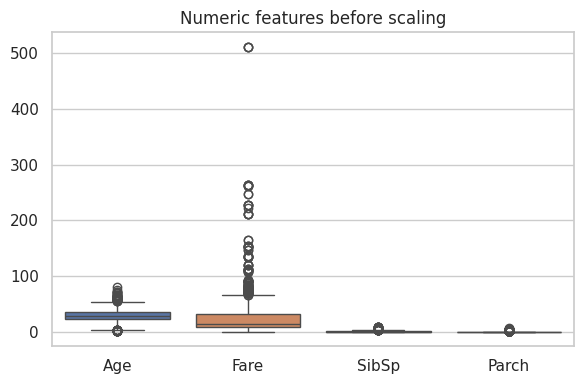

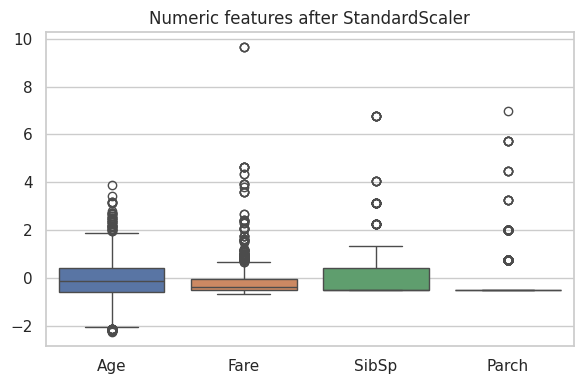

Before scaling — Fare sample stats:
count    891.00
mean      32.20
std       49.69
min        0.00
25%        7.91
50%       14.45
75%       31.00
max      512.33
Name: Fare, dtype: float64

After scaling — Fare sample stats:
count    891.0000
mean       0.0000
std        1.0006
min       -0.6484
25%       -0.4891
50%       -0.3574
75%       -0.0242
max        9.6672
Name: Fare, dtype: float64


In [9]:
# 7. Scaling Numeric Features

score_cols = ["Age", "Fare", "SibSp", "Parch"]

# Boxplot before scaling — shows original value ranges
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_model[score_cols])
plt.title("Numeric features before scaling")
plt.tight_layout()
plt.show()

# Now we apply StandardScaler to the numeric columns
# StandardScaler transforms each column to have mean=0 and std=1
scaler = StandardScaler()

# Here we copy df_model and scale just the numeric columns
df_scaled = df_model.copy()
df_scaled[score_cols] = scaler.fit_transform(df_model[score_cols])

# Boxplot after scaling — now all columns are in a similar range
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_scaled[score_cols])
plt.title("Numeric features after StandardScaler")
plt.tight_layout()
plt.show()

print("Before scaling — Fare sample stats:")
print(df_model["Fare"].describe().round(2))
print()
print("After scaling — Fare sample stats:")
print(df_scaled["Fare"].describe().round(4))

### 📊 Boxplot (Before Scaling) কীভাবে Observe করব?

- X-axis-এ প্রতিটি feature, Y-axis-এ value range
- `Fare`-এর box অনেক উপরে (0–512 range) — `SibSp` ও `Parch`-এর তুলনায় অনেক বড়
- এই range পার্থক্যের কারণে ML model `Fare`-কে অন্যায়ভাবে বেশি গুরুত্ব দিতে পারে

### 📊 Boxplot (After Scaling) কীভাবে Observe করব?

- এখন সব feature-এর box প্রায় একই জায়গায় (-3 থেকে +3 range)
- `Fare` ও `Age` এখন একই scale-এ — সব feature সমান সুযোগ পাচ্ছে
- Outlier dots এখনও দেখা যায়, কিন্তু relative scale-এ তারা অনেক ছোট

### 📊 এই Charts থেকে কী Observe করলাম?

#### Your observations on scaling

- **Sentence 1:**
  Before scaling, `Fare` had values from 0 to 512 while `SibSp` had values only from 0 to 8. After using `StandardScaler`, all numeric columns now have a mean close to 0 and a standard deviation of 1, so they all live in the same small range.

- **Sentence 2:**
  Scaling is very important for models like Logistic Regression, KNN, and SVM because these models use distance calculations. Without scaling, a large-range feature like `Fare` would dominate the model and make small-range features like `SibSp` nearly invisible.

---
### 8. Simple Feature Quality Check (5 marks)
**Tasks:**
- Show `.info()` of the final processed DataFrame (`df_scaled`).
- Confirm there are no missing values.
- Confirm that all remaining features are numeric and suitable for most ML models.
- Write **one short concluding remark** about dataset readiness.


In [10]:
# 8. Simple Feature Quality Check
print(df_scaled.info())

print("\nTotal missing values in final DataFrame:", df_scaled.isna().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Age         891 non-null    float64
 2   Fare        891 non-null    float64
 3   SibSp       891 non-null    float64
 4   Parch       891 non-null    float64
 5   Sex_female  891 non-null    float64
 6   Sex_male    891 non-null    float64
 7   Embarked_C  891 non-null    float64
 8   Embarked_Q  891 non-null    float64
 9   Embarked_S  891 non-null    float64
 10  Pclass_1    891 non-null    float64
 11  Pclass_2    891 non-null    float64
 12  Pclass_3    891 non-null    float64
dtypes: float64(12), int64(1)
memory usage: 90.6 KB
None

Total missing values in final DataFrame: 0


**এই code-এ কী কী করা হয়েছে:**

`df_scaled.info()` → প্রতিটি column-এর dtype ও non-null count দেখানো হয়েছে।
`df_scaled.isna().sum().sum()` → সব column-এ মোট কতটি missing value আছে সেটা count করা হয়েছে।

**পরিবর্তন লক্ষ্যনীয়:**
- সব column-এর dtype এখন `float64` বা `int64` — সব numeric
- Total missing values = **0** — কোনো missing নেই
- Dataset এখন ML model-এ দেওয়ার জন্য সম্পূর্ণ ready

#### Final remark on dataset readiness

- **Your remark:**
  The Titanic dataset is now fully ready for machine learning. All missing values have been handled (Cabin dropped, Age filled with median, Embarked filled with mode). All categorical columns have been one-hot encoded into numeric columns. All numeric features have been scaled to the same range using StandardScaler. There are zero missing values and no text columns left. We can directly use `df_scaled` to train a classification model to predict passenger survival.

---
## Submission
- Run all cells from top to bottom to make sure everything works.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.